Saving data.xlsx to data (12).xlsx

===== 데이터 미리보기 =====
  year(year_month)  CPI Inflation Rate  Base Interest Rate  Exchange Rate
0             2023                 3.6                 3.5         1288.0
1             2024                 2.3                 3.0         1472.5
2             2025                 2.1                 2.5         1439.0
3          2025_10                 2.4                 2.5         1424.4
4          2025_11                 2.4                 2.5         1470.6

### Correlation Matrix ###

                    Base Interest Rate  Exchange Rate  CPI Inflation Rate
Base Interest Rate            1.000000      -0.726807            0.870572
Exchange Rate                -0.726807       1.000000           -0.807580
CPI Inflation Rate            0.870572      -0.807580            1.000000


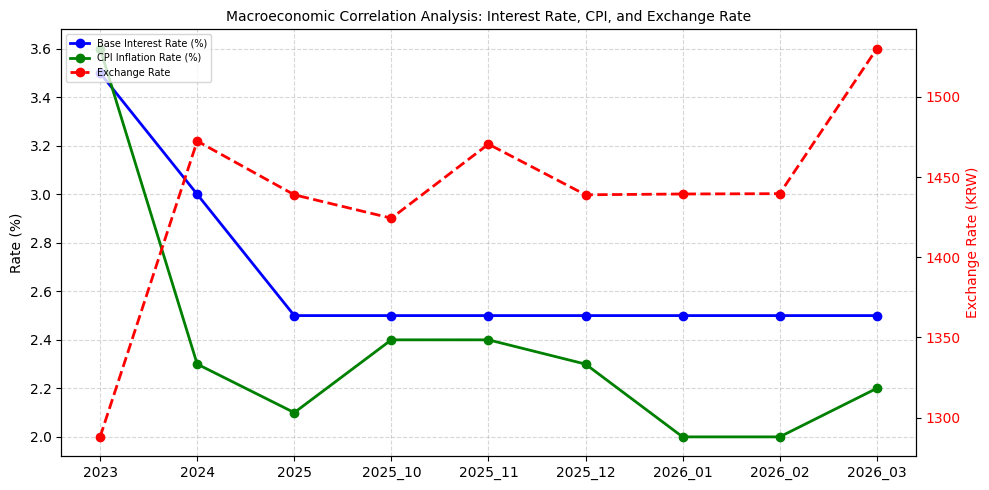

In [14]:
# ============================================================
# Macroeconomic Correlation Analysis
# CPI Inflation Rate
# Base Interest Rate
# Exchange Rate
# ============================================================
# [실습 내용]
# 1. data.xlsx 업로드
# 2. 상관계수 행렬 계산
# 3. 시계열 추이 시각화
# 4. CPI = 초록색
# 5. 기준금리 = 파란색
# 6. 환율 = 빨간색(보조축)
# 7. x축은 원본 year(year_month) 값을 그대로 사용
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
import io

# ------------------------------------------------------------
# 파일 업로드
# ------------------------------------------------------------
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(
    io.BytesIO(uploaded[file_name])
)

# ------------------------------------------------------------
# 데이터 확인
# ------------------------------------------------------------
print("\n===== 데이터 미리보기 =====")
print(df.head())

# ------------------------------------------------------------
# x축 데이터
# (날짜 변환하지 않고 문자열 그대로 사용)
# ------------------------------------------------------------
x = df['year(year_month)'].astype(str)

# ------------------------------------------------------------
# 상관분석
# ------------------------------------------------------------
corr_matrix = df[
    [
        'Base Interest Rate',
        'Exchange Rate',
        'CPI Inflation Rate'
    ]
].corr()

print("\n### Correlation Matrix ###\n")
print(corr_matrix.round(6))

# ------------------------------------------------------------
# 그래프 생성
# ------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(10, 5))

# ------------------------------------------------------------
# 기준금리 (파란색)
# ------------------------------------------------------------
line1 = ax1.plot(
    x,
    df['Base Interest Rate'],
    color='blue',
    marker='o',
    linewidth=2,
    label='Base Interest Rate (%)'
)

# ------------------------------------------------------------
# CPI (초록색)
# ------------------------------------------------------------
line2 = ax1.plot(
    x,
    df['CPI Inflation Rate'],
    color='green',
    marker='o',
    linewidth=2,
    label='CPI Inflation Rate (%)'
)

ax1.set_ylabel("Rate (%)")

# ------------------------------------------------------------
# 환율 (빨간색, 보조축)
# ------------------------------------------------------------
ax2 = ax1.twinx()

line3 = ax2.plot(
    x,
    df['Exchange Rate'],
    color='red',
    linestyle='--',
    marker='o',
    linewidth=2,
    label='Exchange Rate'
)

ax2.set_ylabel(
    "Exchange Rate (KRW)",
    color='red'
)

ax2.tick_params(
    axis='y',
    labelcolor='red'
)

# ------------------------------------------------------------
# 제목
# ------------------------------------------------------------
plt.title(
    "Macroeconomic Correlation Analysis: Interest Rate, CPI, and Exchange Rate",
    fontsize=10
)

# ------------------------------------------------------------
# 범례 통합
# ------------------------------------------------------------
lines = line1 + line2 + line3

labels = [line.get_label() for line in lines]

ax1.legend(
    lines,
    labels,
    loc='upper left',
    fontsize=7
)

# ------------------------------------------------------------
# x축 설정
# ------------------------------------------------------------
plt.xlabel("Year (Year_Month)")

plt.xticks(
    rotation=45,
    fontsize=8
)

# ------------------------------------------------------------
# 격자 표시
# ------------------------------------------------------------
ax1.grid(
    True,
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

plt.show()